# Credit Card Fraud Detection — EDA
Basic exploration of the dataset before training unsupervised models.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/creditcard.csv')
print('Shape:', df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Basic Info

In [2]:
# Data types and missing values
print('Columns:', list(df.columns))
print('\nMissing values:', df.isnull().sum().sum())
print('\nData types:')
print(df.dtypes)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values: 0

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [3]:
# Basic statistics
df[['Time', 'Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


In [11]:
"Most transactions are small — median is only $22. But std is $250, meaning there are some very large outliers. Fraud transactions tend to cluster at small amounts like $1 (test transactions by fraudsters) — which our model picks up." 

'Most transactions are small — median is only $22. But std is $250, meaning there are some very large outliers. Fraud transactions tend to cluster at small amounts like $1 (test transactions by fraudsters) — which our model picks up.'

## 2. Class Distribution

In [4]:
normal = (df['Class'] == 0).sum()
fraud  = (df['Class'] == 1).sum()

print(f'Normal transactions : {normal:,}  ({normal/len(df)*100:.2f}%)')
print(f'Fraud  transactions : {fraud:,}   ({fraud/len(df)*100:.3f}%)')
print('\nDataset is highly imbalanced — fraud is very rare!')

Normal transactions : 284,315  (99.83%)
Fraud  transactions : 492   (0.173%)

Dataset is highly imbalanced — fraud is very rare!


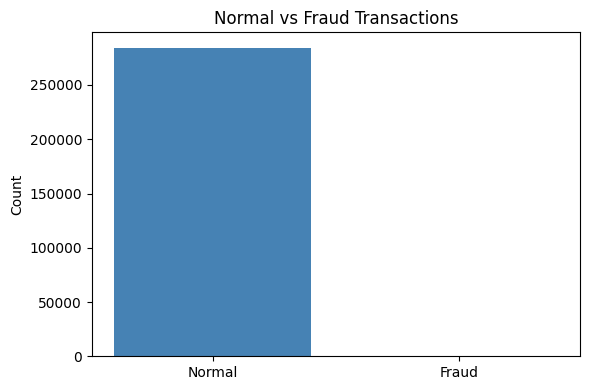

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(['Normal', 'Fraud'], [normal, fraud], color=['steelblue', 'crimson']) #plt.bar(x_axis_labels, heights_of_bars)
plt.title('Normal vs Fraud Transactions')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Amount — Normal vs Fraud

In [6]:
print('Amount statistics by class:')
print(df.groupby('Class')['Amount'].describe().round(2))

Amount statistics by class:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


## 4. Why Unsupervised Learning?

- Fraud is only **0.17%** of data — too few examples for supervised learning
- Features (V1–V28) are PCA-transformed — no real-world meaning
- We don't need labels — just learn what **normal** looks like and flag anything different

**Models:**
- `Isolation Forest` — detects outliers using random trees
- `Autoencoder` — learns normal patterns; high error = fraud